In [1]:
import sys
from pathlib import Path
from PIL import Image
import torch
import torchvision
import torch.nn as nn
import csv
import matplotlib.pyplot as plt
import random


# corent git repo 
CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet")
sys.path.insert(0, str(CORN_NET_REPO))

import cornet
print("Imported cornet from:", cornet.__file__)


Imported cornet from: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py


In [2]:
#load best checkpoint from training, put it on a gpu 
CKPT_PATH = Path("/zpool/vladlab/data_drive/geogaze_data/cornetS_openimages/training_v5_images/weights_identification/best_checkpoint.pth.tar")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(CKPT_PATH)
print("Device:", device)

/zpool/vladlab/data_drive/geogaze_data/cornetS_openimages/training_v5_images/weights_identification/best_checkpoint.pth.tar
Device: cuda:0


In [3]:
ckpt = torch.load(CKPT_PATH, map_location="cpu")

In [4]:
sd = ckpt["state_dict"]

# show any keys that contain "decoder" or "linear"
decoder_keys = [k for k in sd.keys() if "decoder" in k or "linear" in k]
print("Found", len(decoder_keys), "matching keys. First 30:")
for k in decoder_keys[:30]:
    print(k)


Found 2 matching keys. First 30:
module.decoder.linear.weight
module.decoder.linear.bias


In [5]:
num_classes = 433
print(num_classes)

print(ckpt["state_dict"]["module.decoder.linear.weight"].shape)
print("433 for v5, 440 for v3 output feautures, 512 input features")


433
torch.Size([433, 512])
433 for v5, 440 for v3 output feautures, 512 input features


In [6]:
#build coret-s with the length   for v3, 433 for v5 head attached after the 512 output layer

model = cornet.cornet_s(pretrained=False, map_location="cpu")  # build on CPU for now becuase model training, move to gopu later if needed 
# Replace the head exactly like training
# (Your training script hardcoded in_features=512; keep that consistent.)
try:
    m = model.module
except AttributeError:
    m = model

m.decoder.linear = nn.Linear(512, num_classes)
print("Decoder out_features now (should be 433 for v5 same as OpenImage categories):", m.decoder.linear.out_features)

Decoder out_features now (should be 433 for v5 same as OpenImage categories): 433


In [7]:
print(ckpt["state_dict"])

OrderedDict({'module.V1.conv1.weight': tensor([[[[ 1.2110e-02,  1.9979e-02,  1.2410e-02,  ...,  1.2491e-02,
            1.2869e-02, -1.8247e-02],
          [ 1.9069e-02, -1.7360e-02, -3.3331e-02,  ...,  1.1492e-02,
           -3.1268e-02,  8.2554e-04],
          [-1.1660e-02, -7.7240e-03, -2.1960e-02,  ...,  8.0542e-03,
           -1.0708e-03, -6.1581e-04],
          ...,
          [-2.9563e-02, -3.0545e-02, -2.8164e-02,  ..., -3.5967e-02,
           -2.5372e-02,  7.3383e-03],
          [ 3.3988e-04,  2.1288e-03, -1.8752e-02,  ..., -1.9172e-02,
            1.2220e-02, -8.6132e-03],
          [-7.0103e-03, -1.7206e-02,  6.6805e-03,  ...,  4.0149e-03,
           -4.1969e-04,  4.0786e-04]],

         [[-1.4303e-03, -8.7879e-04,  2.0402e-02,  ..., -5.2723e-03,
           -9.5155e-05,  3.3596e-02],
          [-2.1318e-02, -3.5956e-03,  3.2059e-03,  ...,  1.3833e-02,
           -3.3621e-02,  2.4131e-03],
          [ 5.4132e-03, -7.6769e-03,  4.9265e-03,  ...,  8.3113e-03,
            2.4203e

In [8]:
ckpt["state_dict"]
print(type(model))

<class 'torch.nn.parallel.data_parallel.DataParallel'>


In [9]:
#load checkpoint into state dict
state_dict = ckpt["state_dict"]
# strip DataParallel module. starting if it is there becuase the model has something like "module.decoder.linear blqh blah" and we want it with no module
def strip_module_prefix(state_dict):
    #find a key that starts with model (bc want to load the checkpoint into )
    if not any(k.startswith("module.") for k in state_dict.keys()):
        return state_dict
    return {k.replace("module.", "", 1): v for k, v in state_dict.items()}

state_dict_no_module = strip_module_prefix(state_dict)

#load state dict from checkpoint behind the module key (behind the dataparallel wrapper )
incompat = model.module.load_state_dict(state_dict_no_module, strict=True)


#see if ther are any any checkpoint keys are missing or do not line up
print("Loaded.")
print("Missing keys:", incompat.missing_keys)
print("Unexpected keys:", incompat.unexpected_keys)


Loaded.
Missing keys: []
Unexpected keys: []


In [10]:
print(model.module.decoder)

Sequential(
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (flatten): Flatten()
  (linear): Linear(in_features=512, out_features=433, bias=True)
  (output): Identity()
)


In [11]:
model.eval()
model = model.to("cuda")  #move to gpu

In [12]:
###imagenet transformations same as were used on training images:
normalize = torchvision.transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
###fucntion from run.py script
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    normalize,
])

In [13]:
img_path = "/zpool/vladlab/data_drive/stimulus_sets/geogaze_open_images_stim/openimages_working/v5/train/0a0a7b0e4f3756bd.jpg" #path to one image


#turn it tinto a PIL image object where each pixel is RBG value 
img = Image.open(img_path).convert("RGB")
#turns image into a tensor that the model wants 
x = transform(img).unsqueeze(0).to("cuda")  

#do not track gradients becuase I am not training. Only track gradiants while training 
with torch.no_grad():
    logits = model(x) #logits are the number jumle that happens after the image goes through the model

print("Logits shape:", logits.shape)  #linear list of numbers that will become proabilities (length 440 for v3, 433 for v5)

print (logits)

Logits shape: torch.Size([1, 433])
tensor([[-4.9708, -6.6819, -4.7570, -6.5451, -6.3282, -6.1970, -6.5578, -7.1697,
         -6.0417, -6.8560, -7.0487, -5.2620, -6.0007, -2.7875, -6.4916, -6.5378,
         -6.3747, -6.0553, -6.1240, -6.4126, -6.5226, -6.8175, -6.6390, -6.0338,
         -6.9250, -5.6889, -6.3831, -4.8718, -6.5405, -1.0666, -6.4838, -6.6302,
         -5.9546, -6.3061, -6.2218, -4.9328, -4.5599, -7.0142, -5.2983, -6.3307,
         -4.9993, -6.7106, -6.7182, -6.8049, -6.3922, -6.6354, -6.6051, -6.2192,
         -6.9125, -6.0393, -6.6746, -6.5047, -6.1117, -6.6183, -6.2550, -6.6384,
         -7.1523, -5.4716, -6.8059, -5.2372, -6.9878, -6.9897, -6.7427, -6.7978,
         -4.4693, -7.0871, -6.7064, -5.9089, -6.3916, -6.1658, -4.9913, -6.7601,
         -4.9604, -4.8939, -5.9496, -4.3196, -6.1140, -6.3610, -5.3760, -6.8886,
         -6.7180, -6.1759, -6.3097, -6.5284, -5.8486, -5.6037, -6.7977, -5.6638,
         -6.2875, -5.6341, -5.5082, -5.9278, -6.0096, -5.3148, -5.7772, -6

In [14]:
#turn these into probabilites by using sigmoid on the logits becuase thats what BCELogit does 
probs = torch.sigmoid(logits)
probs = probs.squeeze(0)  # remove batch dimetnion 
print(probs)


tensor([0.0069, 0.0013, 0.0085, 0.0014, 0.0018, 0.0020, 0.0014, 0.0008, 0.0024,
        0.0011, 0.0009, 0.0052, 0.0025, 0.0580, 0.0015, 0.0014, 0.0017, 0.0023,
        0.0022, 0.0016, 0.0015, 0.0011, 0.0013, 0.0024, 0.0010, 0.0034, 0.0017,
        0.0076, 0.0014, 0.2561, 0.0015, 0.0013, 0.0026, 0.0018, 0.0020, 0.0072,
        0.0104, 0.0009, 0.0050, 0.0018, 0.0067, 0.0012, 0.0012, 0.0011, 0.0017,
        0.0013, 0.0014, 0.0020, 0.0010, 0.0024, 0.0013, 0.0015, 0.0022, 0.0013,
        0.0019, 0.0013, 0.0008, 0.0042, 0.0011, 0.0053, 0.0009, 0.0009, 0.0012,
        0.0011, 0.0113, 0.0008, 0.0012, 0.0027, 0.0017, 0.0021, 0.0068, 0.0012,
        0.0070, 0.0074, 0.0026, 0.0131, 0.0022, 0.0017, 0.0046, 0.0010, 0.0012,
        0.0021, 0.0018, 0.0015, 0.0029, 0.0037, 0.0011, 0.0035, 0.0019, 0.0036,
        0.0040, 0.0027, 0.0024, 0.0049, 0.0031, 0.0019, 0.0051, 0.0029, 0.0013,
        0.0016, 0.0044, 0.0027, 0.0011, 0.0029, 0.0012, 0.0033, 0.0012, 0.0009,
        0.0010, 0.0012, 0.0012, 0.0041, 

In [16]:
topk = 10
values, indices = torch.topk(probs, topk)

for v, i in zip(values, indices):
    print(f"ind {i.item():3d} → {v.item():.4f}")


ind  29 → 0.2561
ind 345 → 0.1232
ind  13 → 0.0580
ind 374 → 0.0390
ind 313 → 0.0383
ind 329 → 0.0276
ind 270 → 0.0184
ind 158 → 0.0181
ind 126 → 0.0178
ind 293 → 0.0159


In [17]:
#####SAME MAPPING FUNCTION AS THE RUN CSV
def build_label_map_from_csv(csv_path, expected_classes=440):
    """
    Reads a bbox CSV and returns a dict: LabelName (str) -> class_index (int).
    Uses sorted unique labels so the mapping is deterministic, so it will be the same mapping for every run
    Ex. [('/m/011k07', 0), ('/m/012074', 1), ('/m/0120dh', 2), ('/m/01226z', 3), ('/m/012n7d', 4)]
    """
    #create empty set 
    labels = set()

    #read each csv rows as dictionarieskeyed by column name, groaps the LabelName value and ads it to the set (no diplicates in set)
    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            labels.add(row["LabelName"])
    #alphabetizes it and checks that the number of unique labels names matches the number of expected classes (440 for v3, 433 for v5)
    labels = sorted(labels)
    if expected_classes is not None and len(labels) != expected_classes:
        print(f"WARNING: found {len(labels)} unique LabelName values in {csv_path} "
              f"(expected {expected_classes}).")
        
    #gives each LabelName an idx  and is the mapping that will be used to fil last linear layer 
    return {lab: i for i, lab in enumerate(labels)}

In [20]:
#map them back to the labels 
label_to_idx = build_label_map_from_csv("/zpool/vladlab/data_drive/geogaze_data/annotations/v5/filtered_bb_annotations/train-annotations-bbox.filtered.v5.csv", expected_classes=433)
idx_to_label = {v: k for k, v in label_to_idx.items()}
print (idx_to_label)

{0: '/m/011k07', 1: '/m/012074', 2: '/m/0120dh', 3: '/m/01226z', 4: '/m/012n7d', 5: '/m/012w5l', 6: '/m/012xff', 7: '/m/012ysf', 8: '/m/0130jx', 9: '/m/013y1f', 10: '/m/01432t', 11: '/m/014y4n', 12: '/m/0152hh', 13: '/m/015p6', 14: '/m/015qbp', 15: '/m/015qff', 16: '/m/0162_1', 17: '/m/0167gd', 18: '/m/016m2d', 19: '/m/0174k2', 20: '/m/0174n1', 21: '/m/0175cv', 22: '/m/0176mf', 23: '/m/017ftj', 24: '/m/018j2', 25: '/m/018p4k', 26: '/m/01940j', 27: '/m/0199g', 28: '/m/019h78', 29: '/m/019jd', 30: '/m/019w40', 31: '/m/01_5g', 32: '/m/01b638', 33: '/m/01b7fy', 34: '/m/01bfm9', 35: '/m/01bjv', 36: '/m/01bl7v', 37: '/m/01bms0', 38: '/m/01bqk0', 39: '/m/01btn', 40: '/m/01c648', 41: '/m/01cmb2', 42: '/m/01d380', 43: '/m/01dws', 44: '/m/01dxs', 45: '/m/01dy8n', 46: '/m/01f8m5', 47: '/m/01fh4r', 48: '/m/01g3x7', 49: '/m/01gkx_', 50: '/m/01gllr', 51: '/m/01gmv2', 52: '/m/01h3n', 53: '/m/01h44', 54: '/m/01h8tj', 55: '/m/01j3zr', 56: '/m/01j4z9', 57: '/m/01j51', 58: '/m/01j5ks', 59: '/m/01j61q', 6

    LabelName    DisplayName
0     /m/0mkg      Accordion
1  /m/03m3vtv  Adhesive tape
2     /m/0k5j       Aircraft
3   /m/046dlr    Alarm clock
4     /m/0pcr         Alpaca
{0: 'Tortoise', 1: 'Magpie', 2: 'Sea turtle', 3: 'Football', 4: 'Ambulance', 5: 'Ladder', 6: 'Toothbrush', 7: 'Syringe', 8: 'Sink', 9: 'Organ (Musical Instrument)', 10: 'Cassette deck', 11: 'Paddle', 12: 'Snowman', 13: 'Bird', 14: 'Parking meter', 15: 'Traffic light', 16: 'Towel', 17: 'Doll', 18: 'Skull', 19: 'Washing machine', 20: 'Glove', 21: 'Tick', 22: 'Belt', 23: 'Sunglasses', 24: 'Banjo', 25: 'Cart', 26: 'Backpack', 27: 'Bicycle', 28: 'Centipede', 29: 'Boat', 30: 'Surfboard', 31: 'Chopsticks', 32: 'Boot', 33: 'Headphones', 34: 'Shorts', 35: 'Bus', 36: 'Boy', 37: 'Screwdriver', 38: 'Bicycle wheel', 39: 'Barge', 40: 'Laptop', 41: 'Miniskirt', 42: 'Drill (Tool)', 43: 'Bear', 44: 'Brown bear', 45: 'Woodpecker', 46: 'Blue jay', 47: 'Teapot', 48: 'Bow and arrow', 49: 'Swimwear', 50: 'Beehive', 51: 'Brassiere', 52: 

<function matplotlib.pyplot.show(close=None, block=None)>

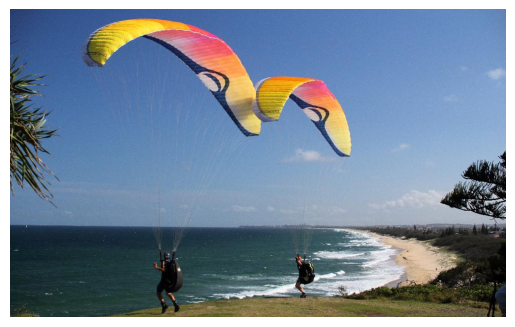

In [21]:
#map labels to categories 
import pandas as pd

cat_csv = "/zpool/vladlab/active_drive/omaltz/scripts/geogaze/openimg_scripts/class-descriptions-boxable.csv"
cat_df = pd.read_csv(cat_csv)

print(cat_df.head())


label_to_cat = dict(zip(cat_df["LabelName"], cat_df["DisplayName"]))

idx_to_label = {v: k for k, v in label_to_idx.items()}


idx_to_cat = {idx: label_to_cat[label] for idx, label in idx_to_label.items()
}
print(idx_to_cat)

topk = 10
values, indices = torch.topk(probs, topk)

for rank, (v, i) in enumerate(zip(values, indices), 1):
    idx = i.item()
    name = idx_to_cat[idx]
    print(f"image preds {rank:2d} {name} {v.item():.4f}")

plt.imshow(img)
plt.axis("off")
plt.show


In [ ]:
import random

folder = Path("/zpool/vladlab/data_drive/stimulus_sets/geogaze_open_images_stim/openimages_working/v5/train")
nimg = 10
top = 10
seed = 567


device = next(model.parameters()).device  # uses whatever device the model is on
model.eval()

# same preprocessing as validation
normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                            std=[0.229, 0.224, 0.225])
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    normalize,
])

# gather images
exts = {".jpg", ".jpeg", ".png", ".webp"}
all_imgs = [p for p in folder.rglob("*") if p.suffix.lower() in exts]
if len(all_imgs) == 0:
    raise RuntimeError(f"Nno ims in folder {sorted(exts)}")

random.seed(seed)
chosen = random.sample(all_imgs, k=min(nimg, len(all_imgs)))

for n, img_path in enumerate(chosen, 1):
    # load + show image
    img = Image.open(img_path).convert("RGB")

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{n}/{len(chosen)}  {img_path.name}")
    plt.show()

    # preprocess + forward
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)                 
        probs = torch.sigmoid(logits)[0]  

    # top-k
    values, indices = torch.topk(probs, top)

    for rank, (v, i) in enumerate(zip(values, indices), 1):
        idx = int(i.item())
        name = idx_to_cat.get(idx, f"(missing display for idx {idx})")
        print(f"{rank:2d} idx: {idx:3d} pred:{name:10s} {v.item():.4f}")


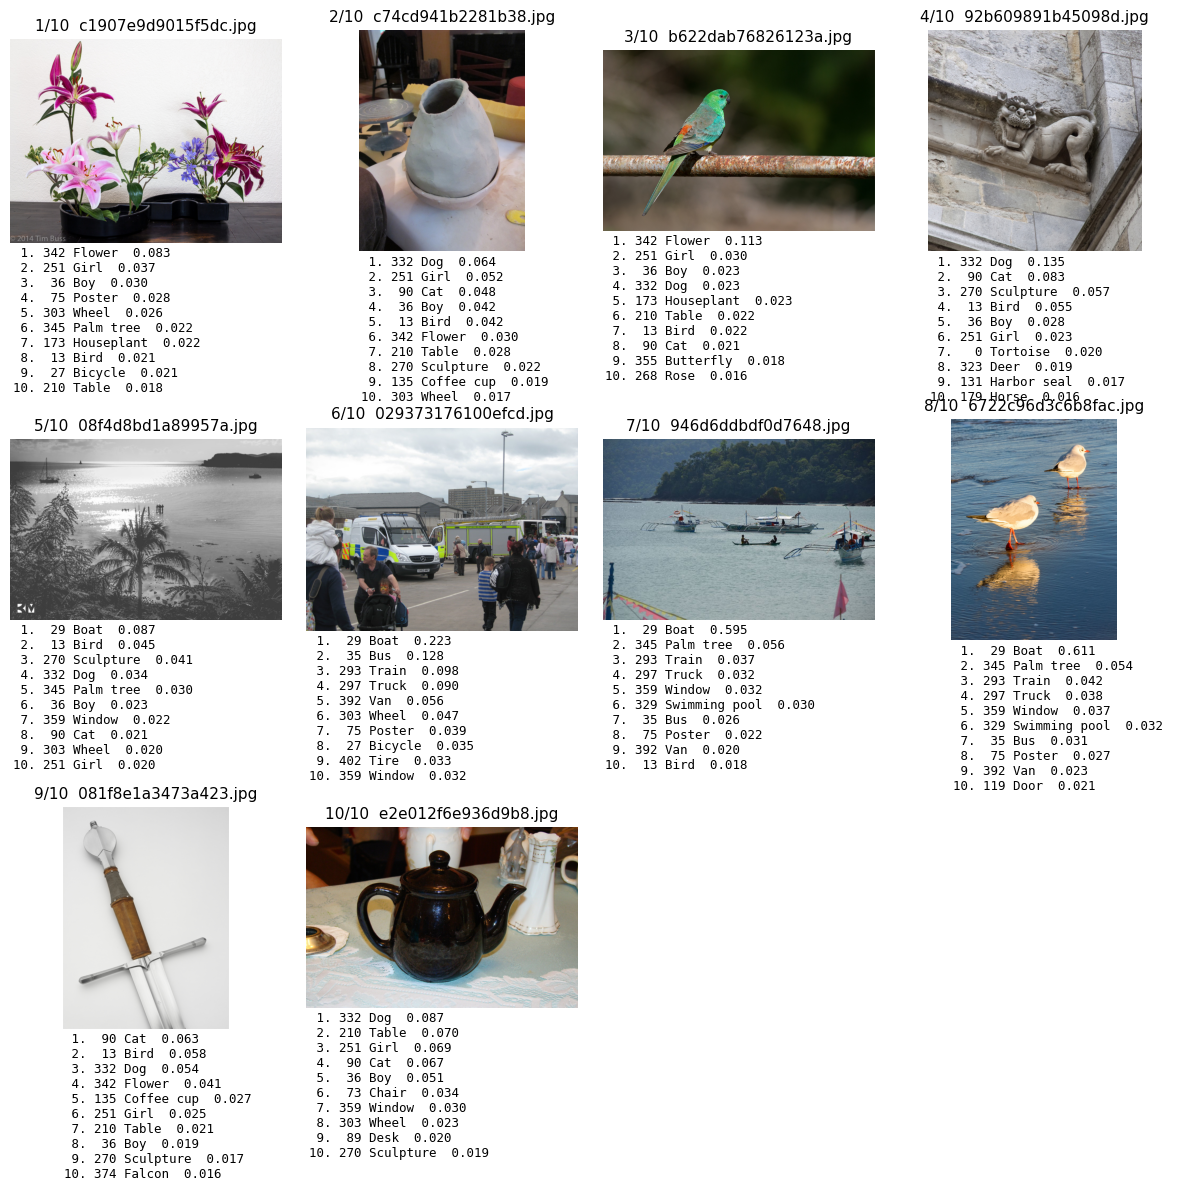

In [22]:
import math

folder = Path("/zpool/vladlab/data_drive/stimulus_sets/geogaze_open_images_stim/openimages_working/v5/train")
nimg = 10
top = 10
seed = 1

device = next(model.parameters()).device  # uses whatever device the model is on
model.eval()

# same preprocessing as validation
normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                            std=[0.229, 0.224, 0.225])
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    normalize,
])

# gather images
exts = {".jpg", ".jpeg", ".png", ".webp"}
all_imgs = [p for p in folder.rglob("*") if p.suffix.lower() in exts]
if len(all_imgs) == 0:
    raise RuntimeError(f"No images in folder with extensions {sorted(exts)}")

random.seed(seed)
chosen = random.sample(all_imgs, k=min(nimg, len(all_imgs)))

# ---- GRID SETTINGS ----
ncols = 4
nrows = math.ceil(len(chosen) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 4 * nrows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, img_path, n in zip(axes, chosen, range(1, len(chosen) + 1)):
    # load image
    img = Image.open(img_path).convert("RGB")

    # preprocess + forward
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)[0]

    # top-k
    values, indices = torch.topk(probs, top)

    # build a multiline string for preds
    lines = []
    for rank, (v, i) in enumerate(zip(values, indices), 1):
        idx = int(i.item())
        name = idx_to_cat.get(idx, f"(missing idx {idx})")
        lines.append(f"{rank:2d}. {idx:3d} {name}  {v.item():.3f}")
    pred_text = "\n".join(lines)

    # draw
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{n}/{len(chosen)}  {img_path.name}", fontsize=11)
    ax.text(
        0.01, -0.02, pred_text,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9, family="monospace"
    )

# turn off any unused axes (if nimg not multiple of 3)
for ax in axes[len(chosen):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [23]:
model = model.to("cpu")
torch.cuda.empty_cache()